# Visualizing Presidental Disaster Declarations in Counties Affected by Hurricane Helene

```{image} ../thumbnails/U.S._Census_Bureau_logo_post-2011.svg.png
:alt: US Census Bureau logo
:width: 200px
```

---

## Overview

Hurricane Helene was a devastating Category 4 hurricane that made landfall in Florida's Big Bend on September 26th, 2024. Helene brought massive amounts of rainfall as it moved northward through the Tennessee Valley and the southern Appalachian Mountains (US Army Corps of Engineers - Nashville District, 2025). Storm surge, widespread flooding, extensive power outages, and wind damage were some of the many impacts caused by Hurricane Helene. Presidential disaster declarations were issued for 299 counties across 8 different states, impacting an estimated 26 million people (Sawyer, 2025).

---

## Import Packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import pandas as pd
from mapclassify import UserDefined
from cartopy import crs as ccrs
from cartopy import feature as cfeature
from metpy.plots import USCOUNTIES

---

## Import CSV Data as a Pandas DataFrame

The dataset is sourced from the US Census Bureau as a part of the [**Census Bureau’s Assessment, Recovery, and Evaluation datasets or CAREs**](https://www.census.gov/programs-surveys/community-resilience-estimates/projects/disaster-recovery/hurricane-helene.html). This dataset curates data from sources such as the Census Bureau, FEMA, DOE, NOAA, and BLS. Data themes include population, exposure, and recovery data for Hurricane Helene.

In [2]:
helene_data = pd.read_csv('/spare11/atm533/ag265895/bluegreen/data/HELENE.csv') #create pandas dataframe

helene_data

,NAME,geoid,DR_COUNT,EM_COUNT,ihProgramDeclared,paProgramDeclared,femaDeclarationString_EM,femaDeclarationString_DR,POPUNI_23,PRED0_E_23,...,haEligibleOwners,onaEligibleOwners,haMaxOwners,validReg_Prop,haEligible_Prop,onaEligible_Prop,ihOwners_P,haEligible_Owners_P,onaEligible_Owners_P,haMax_Owners_P
0,"Autauga County, Alabama",1001,0,1,0,1,EM-3618-AL,NaN,60183,23534,...,-888888888,-888888888,-888888888,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0
1,"Baldwin County, Alabama",1003,0,1,0,1,EM-3618-AL,NaN,251949,91386,...,-888888888,-888888888,-888888888,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0
2,"Barbour County, Alabama",1005,0,1,0,1,EM-3618-AL,NaN,22085,4988,...,-888888888,-888888888,-888888888,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0
3,"Bibb County, Alabama",1007,0,1,0,1,EM-3618-AL,NaN,20223,6880,...,-888888888,-888888888,-888888888,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0
4,"Blount County, Alabama",1009,0,1,0,1,EM-3618-AL,NaN,59729,18973,...,-888888888,-888888888,-888888888,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3139,"Sweetwater County, Wyoming",56037,0,0,0,0,NaN,NaN,40916,14614,...,-888888888,-888888888,-888888888,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0
3140,"Teton County, Wyoming",56039,0,0,0,0,NaN,NaN,23162,7442,...,-888888888,-888888888,-888888888,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0
3141,"Uinta County, Wyoming",56041,0,0,0,0,NaN,NaN,20684,5561,...,-888888888,-888888888,-888888888,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0
3142,"Washakie County, Wyoming",56043,0,0,0,0,NaN,NaN,7647,2654,...,-888888888,-888888888,-888888888,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0,-888888888.0


This dataset includes counties that did not issue a presidential disaster declaration during Hurricane Helene, as well as many NaNs or Not a Number values, which we will filter out to clean up the dataset

In [3]:
helene_data = helene_data.replace([-888888888, -555555555], 0) #replace NaNs with 0

clean_helene_data = helene_data[(helene_data["DR_COUNT"] != 0)] #remove rows with a zero value for major disaster declarations

#calculate and print the number of rows removed 
original_rows = len(helene_data)
print(f"Original number of rows: {original_rows}")

cleaned_rows = len(clean_helene_data)
removed_rows = original_rows - cleaned_rows

print(f"Rows removed: {removed_rows} ")
print(f"Rows remaining: {cleaned_rows}")

#display cleaned up tabular data
clean_helene_data

Original number of rows: 3144
Rows removed: 2845 
Rows remaining: 299


,NAME,geoid,DR_COUNT,EM_COUNT,ihProgramDeclared,paProgramDeclared,femaDeclarationString_EM,femaDeclarationString_DR,POPUNI_23,PRED0_E_23,...,haEligibleOwners,onaEligibleOwners,haMaxOwners,validReg_Prop,haEligible_Prop,onaEligible_Prop,ihOwners_P,haEligible_Owners_P,onaEligible_Owners_P,haMax_Owners_P
322,"Alachua County, Florida",12001,1,1,1,1,EM-3615-FL,DR-4828-FL,269665,100308,...,352,1171,1,7.3,0.4,2.6,43.9,77.9,40.7,100.0
323,"Baker County, Florida",12003,1,0,1,1,NaN,DR-4828-FL,27462,11209,...,73,220,0,10.9,0.9,4.0,62.5,92.4,61.6,0.0
324,"Bay County, Florida",12005,1,1,0,1,EM-3615-FL,DR-4828-FL,188961,65265,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
325,"Bradford County, Florida",12007,1,1,1,1,EM-3615-FL,DR-4828-FL,25524,7218,...,107,239,0,9.7,1.4,4.3,58.4,81.7,61.0,0.0
328,"Calhoun County, Florida",12013,1,1,0,1,EM-3615-FL,DR-4828-FL,12159,3297,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2930,"Galax city, Virginia",51640,1,1,1,1,EM-3621-VA,DR-4831-VA,6717,1810,...,53,239,0,40.1,2.2,13.6,59.9,88.3,64.6,0.0
2941,"Norton city, Virginia",51720,1,1,0,1,EM-3621-VA,DR-4831-VA,3492,1215,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2945,"Radford city, Virginia",51750,1,1,1,1,EM-3621-VA,DR-4831-VA,13619,5317,...,2,11,0,3.0,0.0,0.3,36.1,100.0,57.9,0.0
2947,"Roanoke city, Virginia",51770,1,0,0,1,NaN,DR-4831-VA,96730,32164,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---

The CAREs dataset does not include the cartographic boundaries of the affected counties, so we are also going to import and merge the [**GeoPandas’ built-in TIGER/Cartographic Boundary files**](https://www2.census.gov/geo/tiger/GENZ2022) from the U.S. Census Bureau to get the polygon geometry of the counties.

In [4]:
counties = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_county_5m.zip")

counties

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,13,233,00343585,0500000US13233,13233,Polk,Polk County,GA,Georgia,06,803775591,4664760,"POLYGON ((-85.42188 34.08082, -85.28332 34.079..."
1,21,023,00516858,0500000US21023,21023,Bracken,Bracken County,KY,Kentucky,06,524900457,16279752,"POLYGON ((-84.23042 38.8274, -84.23018 38.8265..."
2,28,153,00695797,0500000US28153,28153,Wayne,Wayne County,MS,Mississippi,06,2099745602,7255476,"POLYGON ((-88.94296 31.56566, -88.94272 31.607..."
3,42,001,01213656,0500000US42001,42001,Adams,Adams County,PA,Pennsylvania,06,1343400757,7771555,"POLYGON ((-77.47108 39.94408, -77.42136 39.981..."
4,04,007,00040471,0500000US04007,04007,Gila,Gila County,AZ,Arizona,06,12322070148,96465330,"POLYGON ((-111.72051 34.16039, -111.69497 34.1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3230,27,041,00659466,0500000US27041,27041,Douglas,Douglas County,MN,Minnesota,06,1649506061,215746732,"POLYGON ((-95.76975 46.10745, -95.4853 46.1081..."
3231,47,023,01639732,0500000US47023,47023,Chester,Chester County,TN,Tennessee,06,740053474,575590,"POLYGON ((-88.84161 35.42783, -88.8158 35.4274..."
3232,22,113,00559538,0500000US22113,22113,Vermilion,Vermilion Parish,LA,Louisiana,15,3035611921,932167176,"POLYGON ((-92.72387 30.04865, -92.69763 30.054..."
3233,35,043,00929113,0500000US35043,35043,Sandoval,Sandoval County,NM,New Mexico,06,9609358329,10852149,"MULTIPOLYGON (((-106.27698 35.85555, -106.2483..."


Next, we will drop the columns in the dataset that we don't need.

In [5]:
counties.drop(columns=['STATEFP', 'COUNTYFP', 'COUNTYNS', 'AFFGEOID', 'STUSPS', 'GEOID', 'LSAD', 'ALAND',	'AWATER'],inplace=True)

counties

,NAME,NAMELSAD,STATE_NAME,geometry
0,Polk,Polk County,Georgia,"POLYGON ((-85.42188 34.08082, -85.28332 34.079..."
1,Bracken,Bracken County,Kentucky,"POLYGON ((-84.23042 38.8274, -84.23018 38.8265..."
2,Wayne,Wayne County,Mississippi,"POLYGON ((-88.94296 31.56566, -88.94272 31.607..."
3,Adams,Adams County,Pennsylvania,"POLYGON ((-77.47108 39.94408, -77.42136 39.981..."
4,Gila,Gila County,Arizona,"POLYGON ((-111.72051 34.16039, -111.69497 34.1..."
...,...,...,...,...
3230,Douglas,Douglas County,Minnesota,"POLYGON ((-95.76975 46.10745, -95.4853 46.1081..."
3231,Chester,Chester County,Tennessee,"POLYGON ((-88.84161 35.42783, -88.8158 35.4274..."
3232,Vermilion,Vermilion Parish,Louisiana,"POLYGON ((-92.72387 30.04865, -92.69763 30.054..."
3233,Sandoval,Sandoval County,New Mexico,"MULTIPOLYGON (((-106.27698 35.85555, -106.2483..."


Organize the NAMELSAD and STATE_NAME by alphabetical order to match the order from the helene_data columns

In [6]:
sort_counties = counties.sort_values(by=["STATE_NAME", "NAMELSAD"], ascending=[True, True])

Next, to match the NAME column from the CAREs dataset, we will combine the NAMELSAD column and STATE_NAME column into one column and drop the columns, leaving the geometry column organized in alphabetical order by state and county

In [7]:
#merge the two columns with a comma separator
sort_counties["NAME"] = sort_counties["NAMELSAD"] + ", " + sort_counties["STATE_NAME"]

sort_counties.drop(columns=['NAMELSAD', 'STATE_NAME'],inplace=True)

sort_counties

,NAME,geometry
1842,"Autauga County, Alabama","POLYGON ((-86.9176 32.66417, -86.81657 32.6601..."
567,"Baldwin County, Alabama","POLYGON ((-88.02927 30.22271, -88.02399 30.230..."
414,"Barbour County, Alabama","POLYGON ((-85.74142 31.61961, -85.71615 31.660..."
494,"Bibb County, Alabama","POLYGON ((-87.42194 33.00338, -87.31854 33.006..."
1489,"Blount County, Alabama","POLYGON ((-86.96318 33.86731, -86.92369 33.872..."
...,...,...
3171,"Sweetwater County, Wyoming","POLYGON ((-110.05371 42.27074, -109.47388 42.2..."
1286,"Teton County, Wyoming","POLYGON ((-111.05533 44.66626, -110.98886 44.6..."
1033,"Uinta County, Wyoming","POLYGON ((-111.04655 41.24811, -111.04655 41.2..."
1616,"Washakie County, Wyoming","POLYGON ((-108.55056 44.16846, -107.67755 44.1..."


Let's make sure all of the words in the NAME column for the sort_location_data and clean_helene_data are properly capitalized in order to ensure a correct merge between datasets

In [8]:
sort_counties["NAME"] = sort_counties["NAME"].str.title()

clean_helene_data["NAME"] = clean_helene_data["NAME"].str.title()

/tmp/ipykernel_1643967/3475261936.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_helene_data["NAME"] = clean_helene_data["NAME"].str.title()


---

Using the NAME column, we can now merge together the cleane_helene_data columns and sort_location_data

In [9]:
helene_merged = sort_counties.merge(clean_helene_data, on='NAME', how='inner')

#display the merged dataset
helene_merged

,NAME,geometry,geoid,DR_COUNT,EM_COUNT,ihProgramDeclared,paProgramDeclared,femaDeclarationString_EM,femaDeclarationString_DR,POPUNI_23,...,haEligibleOwners,onaEligibleOwners,haMaxOwners,validReg_Prop,haEligible_Prop,onaEligible_Prop,ihOwners_P,haEligible_Owners_P,onaEligible_Owners_P,haMax_Owners_P
0,"Alachua County, Florida","POLYGON ((-82.65855 29.83014, -82.64138 29.827...",12001,1,1,1,1,EM-3615-FL,DR-4828-FL,269665,...,352,1171,1,7.3,0.4,2.6,43.9,77.9,40.7,100.0
1,"Baker County, Florida","POLYGON ((-82.45958 30.58426, -82.41892 30.581...",12003,1,0,1,1,NaN,DR-4828-FL,27462,...,73,220,0,10.9,0.9,4.0,62.5,92.4,61.6,0.0
2,"Bay County, Florida","POLYGON ((-85.99573 30.27466, -85.99553 30.281...",12005,1,1,0,1,EM-3615-FL,DR-4828-FL,188961,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"Bradford County, Florida","POLYGON ((-82.41565 29.92633, -82.36282 29.934...",12007,1,1,1,1,EM-3615-FL,DR-4828-FL,25524,...,107,239,0,9.7,1.4,4.3,58.4,81.7,61.0,0.0
4,"Calhoun County, Florida","POLYGON ((-85.38966 30.24899, -85.38579 30.480...",12013,1,1,0,1,EM-3615-FL,DR-4828-FL,12159,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,"Tazewell County, Virginia","POLYGON ((-81.89726 37.15223, -81.87519 37.153...",51185,1,1,1,1,EM-3621-VA,DR-4831-VA,37638,...,166,510,2,10.5,1.1,4.1,73.5,95.4,77.5,100.0
295,"Washington County, Virginia","POLYGON ((-82.30865 36.72667, -82.24138 36.753...",51191,1,1,1,1,EM-3621-VA,DR-4831-VA,52505,...,147,356,12,5.0,0.7,2.3,67.5,90.2,69.1,100.0
296,"Wise County, Virginia","POLYGON ((-82.87864 36.89398, -82.87644 36.896...",51195,1,1,1,1,EM-3621-VA,DR-4831-VA,32899,...,28,90,0,2.7,0.2,1.0,59.7,93.3,66.2,0.0
297,"Wythe County, Virginia","POLYGON ((-81.36723 36.96722, -81.35583 36.964...",51197,1,1,1,1,EM-3621-VA,DR-4831-VA,28085,...,111,266,4,4.7,0.9,2.5,78.5,98.2,84.7,100.0


Let's save the new helene_merged dataframe into our data folder so we can use it for future notebooks

In [10]:
helene_merged.to_csv('/spare11/atm533/ag265895/proto-cookbook/data/helene_merged.csv', index=False)

We can see that the dataset is properly cleaned since 299 counties are left, matching the information from the Overview. Now that the dataset is cleaned up and saved, we can continue to visualize the impacted counties

---

## Visualizing Impacted Counties by Hurricane Helene

First, since we are plotting county border geometries, we need to be sure that the geometries are in the same coordinate reference system (CRS) as the map we are using

In [11]:
#ensure that helene_merged and counties are in PlateCarree (lon/lat)
helene_merged = helene_merged.to_crs(epsg=4326)
sort_counties = sort_counties.to_crs(epsg=4326)

---

Now, we will visualize all of the counties that issued a presidential disaster declaration for Hurricane Helene. Each county that issued a declaration will be identified in red.

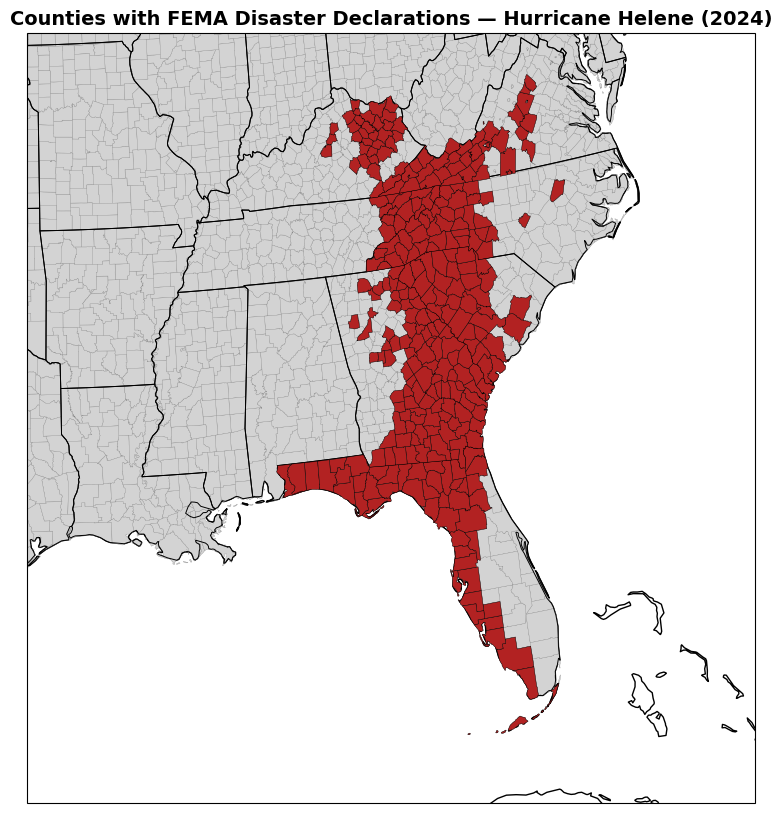

In [32]:
#plot data
fig = plt.figure(figsize=(12, 10))

#define projection and southeast US
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-95, -75, 24, 39], crs=ccrs.PlateCarree())  

#add geographic features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.7, edgecolor='black', zorder=2)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), zorder=1)

#plot all counties in gray
counties.plot(ax=ax, facecolor='lightgray', edgecolor='gray', linewidth=0.2, transform=ccrs.PlateCarree(), zorder=1)

#plot affected counties in red
helene_merged.plot(ax=ax, facecolor='firebrick', edgecolor='black', linewidth=0.3, transform=ccrs.PlateCarree(), zorder=2)

#title and labels
plt.title("Counties with FEMA Disaster Declarations — Hurricane Helene (2024)", fontsize=14, weight='bold')
plt.show()

We can also visualize the number of Individual Assistance registrations
where the home was destroyed by the disaster using the variable 'destroyed'.

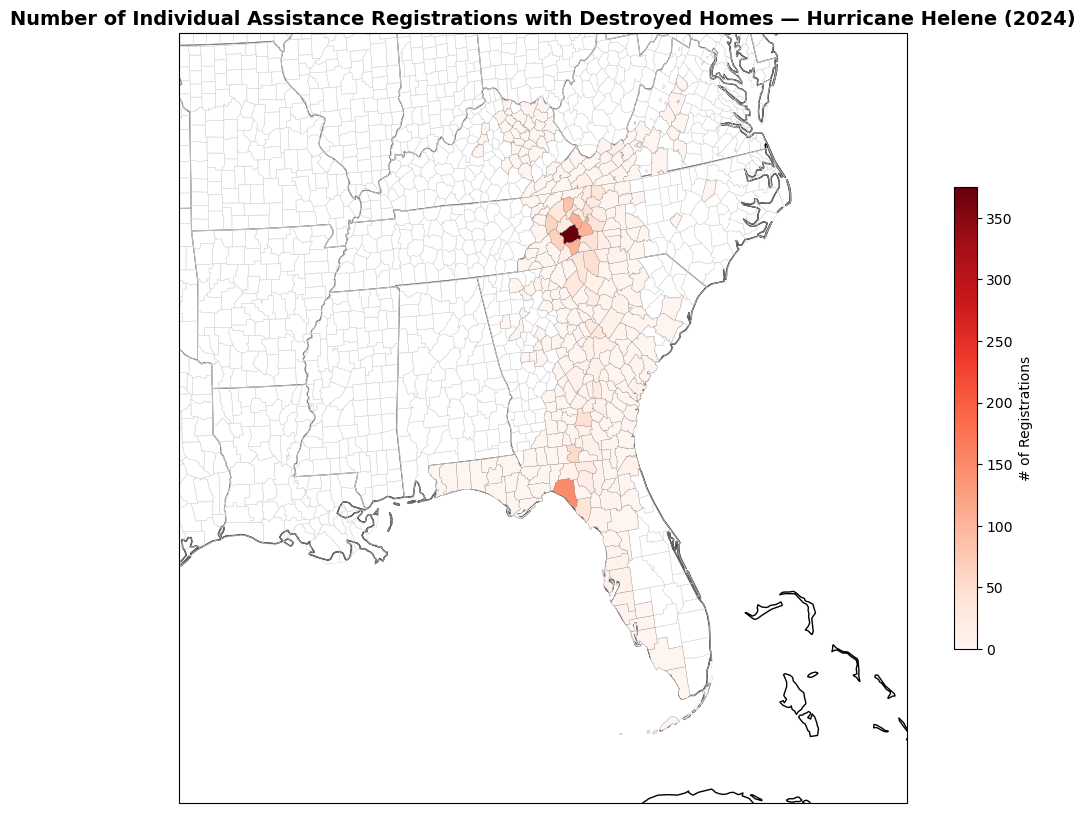

In [34]:
#plot data
fig = plt.figure(figsize=(12, 10))

#define projection and southeast US
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-95, -75, 24, 39], crs=ccrs.PlateCarree())  

#add geographic features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.7, edgecolor='grey', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), zorder=1)

#add US counties
ax.add_feature(USCOUNTIES.with_scale('20m'), facecolor='none', edgecolor='lightgray', linewidth=0.3, zorder=1)

#plot counties shaded by poverty rate
helene_merged.plot(
    column='destroyed',      
    cmap='Reds',                      
    linewidth=0.2,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "# of Registrations", 'shrink': 0.6},
    transform=ccrs.PlateCarree(),
    ax=ax,
    zorder=2
)

#add title
plt.title('Number of Individual Assistance Registrations with Destroyed Homes — Hurricane Helene (2024)', fontsize=14, weight='bold')

plt.show()

How does this compare to the number of valid registrations for the Individual Assistance? We can visualize the relationship between the variables 'destroyed' and 'validReg' with a bar graph.

INSERT HERE ONCE FINISHED

---

## Visualizing Hurricane Helene Impacts in Affected Counties

We can take a deeper look into some of the impacts Hurricane Helene brought that contributed to the presidential disaster declaration by visualizing columns MAX_OUTAGE, MAX_PERCENTAGE_OUT, totPrecip, and Wind_Swath_Max, which look at the maximum amount of customers who experienced a power outage during Helene, the percentage of people who experienced power outages, the amount of percipitation that fell, and the maximum observed wind swath in a county, respectively. 

We'll start with plotting MAX_OUTAGE

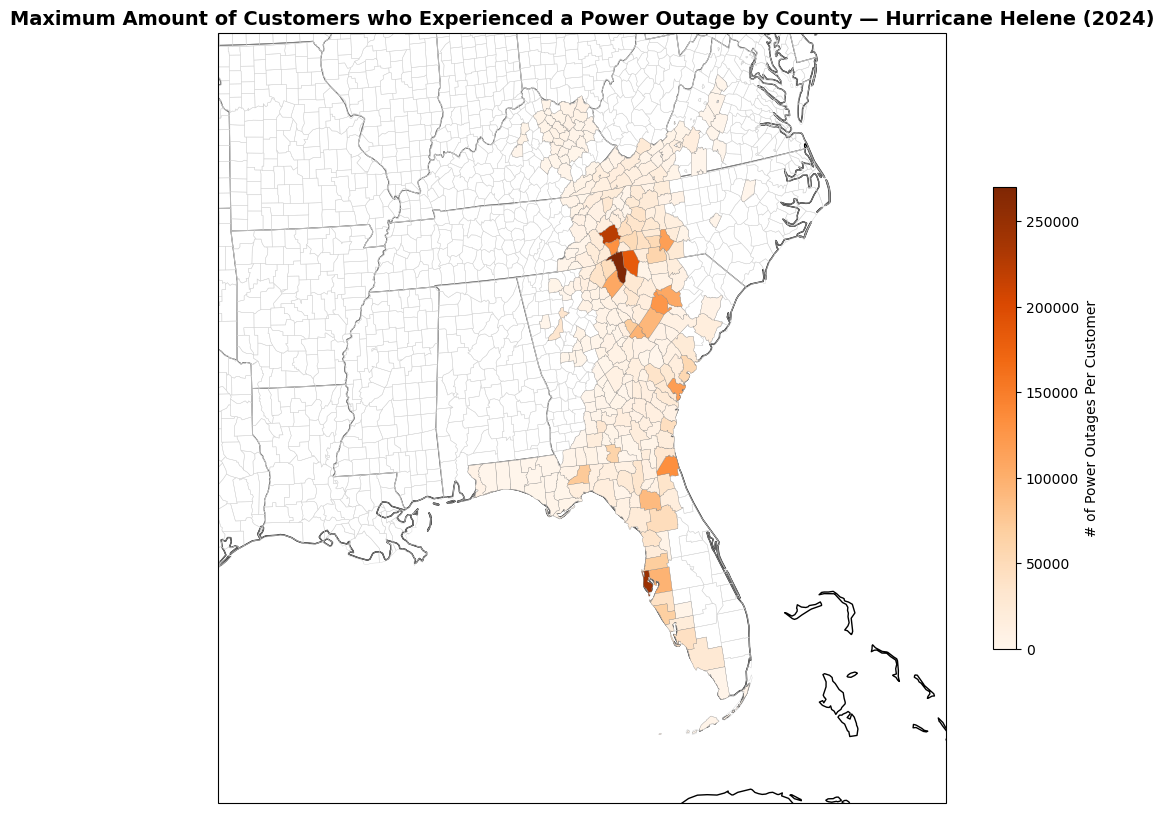

In [13]:
#plot data
fig = plt.figure(figsize=(12, 10))

#define projection and southeast US
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-95, -75, 24, 39], crs=ccrs.PlateCarree())  

#add geographic features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.7, edgecolor='grey', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), zorder=1)

#add US counties
ax.add_feature(USCOUNTIES.with_scale('20m'), facecolor='none', edgecolor='lightgray', linewidth=0.3, zorder=1)

#plot counties shaded by poverty rate
helene_merged.plot(
    column='MAX_OUTAGE',      
    cmap='Oranges',                      
    linewidth=0.2,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "# of Power Outages Per Customer", 'shrink': 0.6},
    transform=ccrs.PlateCarree(),
    ax=ax,
    zorder=2
)

#add title
plt.title('Maximum Amount of Customers who Experienced a Power Outage by County — Hurricane Helene (2024)', fontsize=14, weight='bold')

plt.show()

How does this number compare to the number of people living in each county? We can examine the percentage of customers who experienced a power outage by county by using the variable MAX_PERCENTAGE_OUT.

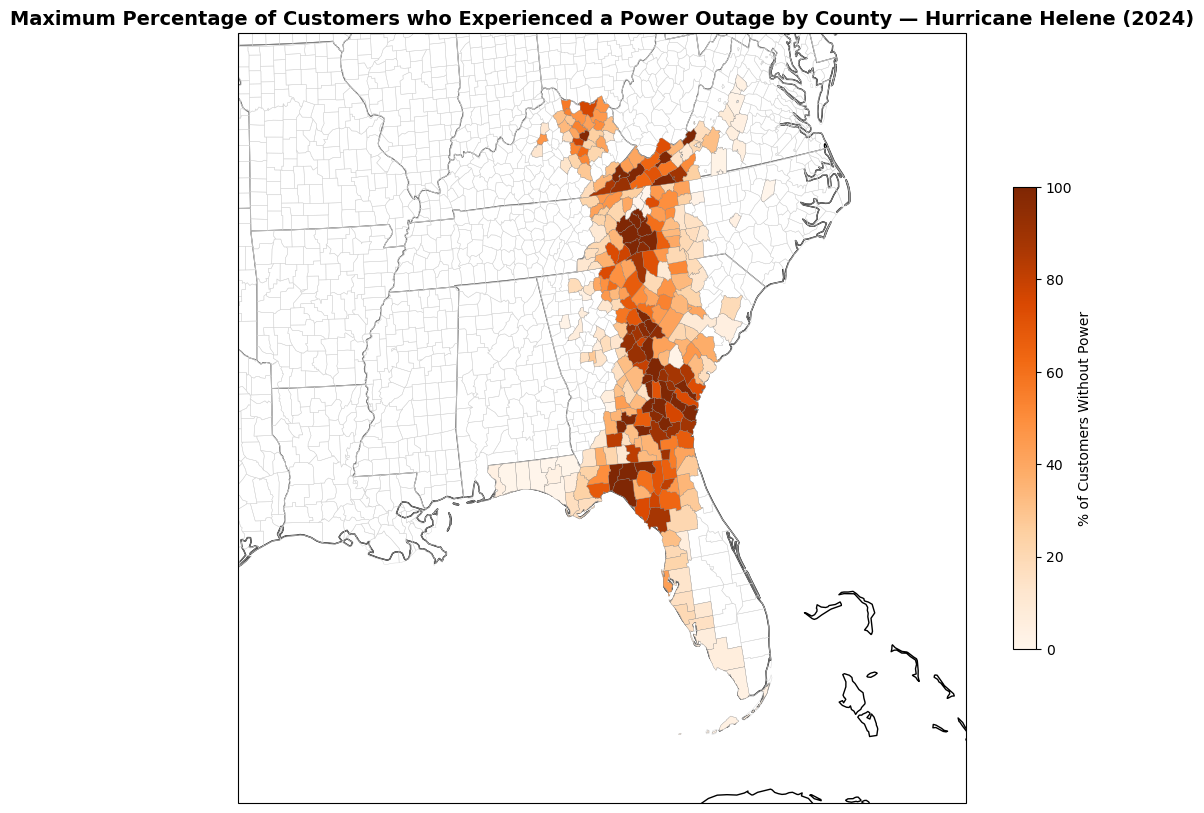

In [14]:
#plot data
fig = plt.figure(figsize=(12, 10))

#define projection and southeast US
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-95, -75, 24, 39], crs=ccrs.PlateCarree())  

#add geographic features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.7, edgecolor='grey', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), zorder=1)

#add US counties
ax.add_feature(USCOUNTIES.with_scale('20m'), facecolor='none', edgecolor='lightgray', linewidth=0.3, zorder=1)

#plot counties shaded by poverty rate
helene_merged.plot(
    column='MAX_PERCENTAGE_OUT',      
    cmap='Oranges',                      
    linewidth=0.2,
    edgecolor='gray',
    legend=True,
    legend_kwds={'label': "% of Customers Without Power", 'shrink': 0.6},
    transform=ccrs.PlateCarree(),
    ax=ax,
    zorder=2
)

#add title
plt.title('Maximum Percentage of Customers who Experienced a Power Outage by County — Hurricane Helene (2024)', fontsize=14, weight='bold')

plt.show()

The map is very different from the MAX_OUTAGE map as it relates the number of customers without power to the number of customers in the county.

---

When plotting Wind_Swath_Max, the process is different because it has defined amounts for the wind swaths, designating them as tropical storm force, hurricane force, etc. We will use UserDefined to make specific bins.

In [30]:
#define bins based on dataset
bins = [0, 34, 50, 64]  

#label each bin
bin_labels = [
    'Below Tropical Storm (<34 kt)',
    'Tropical Storm (34–50 kt)',
    '50-Knot Winds (50–64 kt)',
    'Hurricane-Force (64+ kt)'
]

#create classifier
classifier = UserDefined(helene_merged['Wind_Swath_Max'], bins=bins)

Now we can plot Wind_Swath_Max

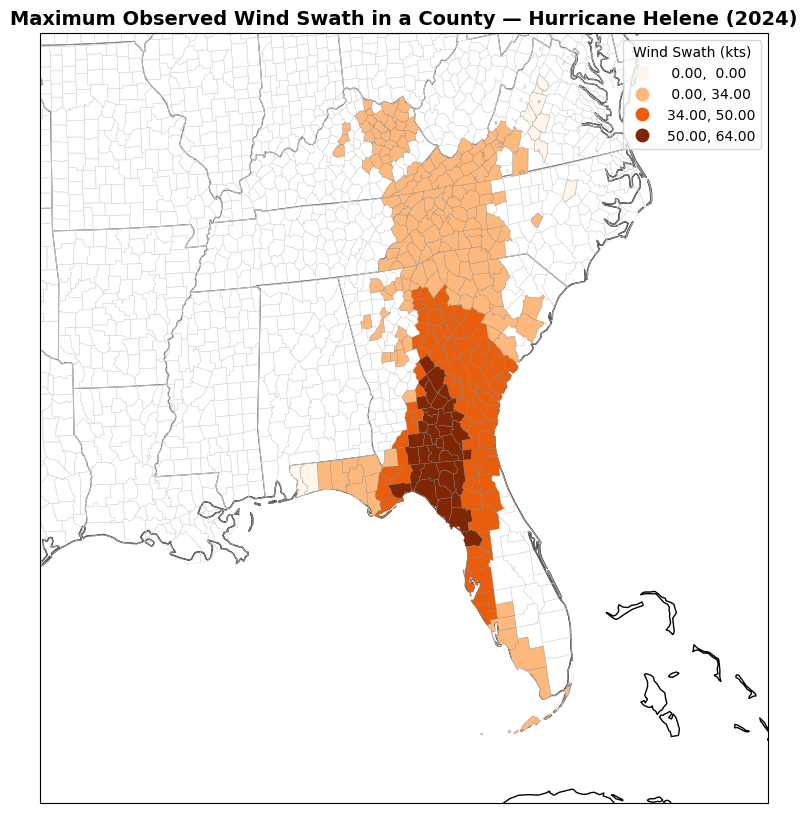

In [31]:
#plot data
fig = plt.figure(figsize=(12, 10))

#define projection and southeast US
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-95, -75, 24, 39], crs=ccrs.PlateCarree())  

#add geographic features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.7, edgecolor='grey', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), zorder=1)

#add US counties
ax.add_feature(USCOUNTIES.with_scale('20m'), facecolor='none', edgecolor='lightgray', linewidth=0.3, zorder=1)

# Plot counties with custom bins
plot = helene_merged.plot(
    column='Wind_Swath_Max',
    cmap='Oranges',
    linewidth=0.2,
    edgecolor='gray',
    legend=True,     
    legend_kwds={'title': "Wind Swath (kts)"},
    scheme='UserDefined',
    classification_kwds={'bins': bins},
    transform=ccrs.PlateCarree(),
    ax=ax,
    zorder=2
)

# Add map title
plt.title('Maximum Observed Wind Swath in a County — Hurricane Helene (2024)', fontsize=14, weight='bold')

plt.show()

With this plot, we can see that the strongest wind swaths coincided with the location of Hurricane Helene's landfall. We can follow the same process to plot total precipitation.

While the process is similar to plotting wind swath, we will be defining custom percentile bins to visualize the most significant location of the rainfall totals, totPrecip.

In [28]:
#define bins based on dataset
p10, p50, p75, p90, p95, p99 = np.percentile(
    helene_merged['totPrecip'].dropna(),
    [10, 50, 75, 90, 95, 99]
)

#define custom percentile bins (in inches)
bins = [p10, p50, p75, p90, p95, p99, helene_merged['totPrecip'].max()]  

#create classifier
classifier = UserDefined(helene_merged['totPrecip'], bins=bins)

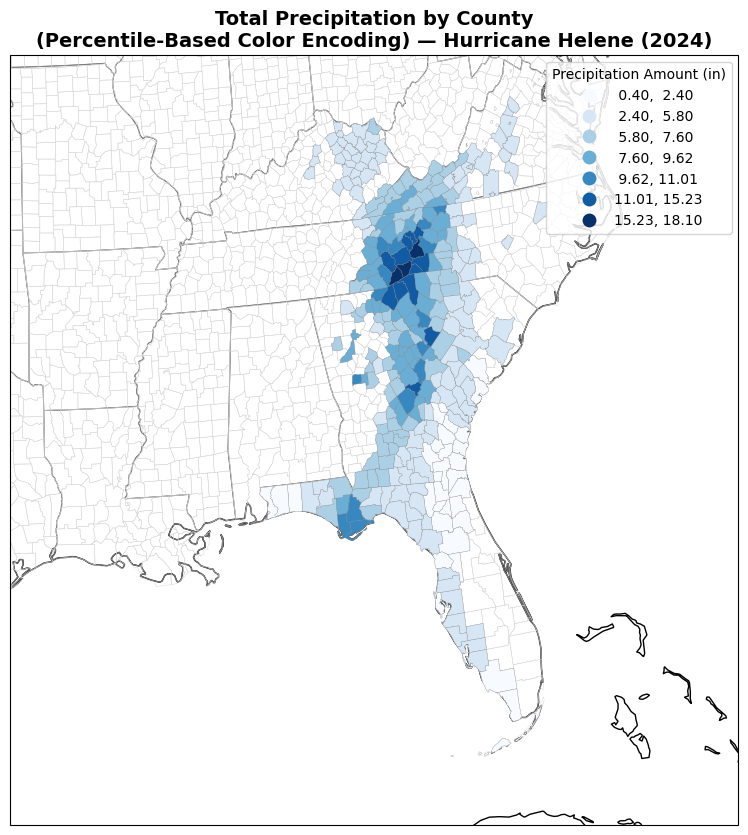

In [29]:
#plot data
fig = plt.figure(figsize=(12, 10))

#define projection and southeast US
ax = plt.axes(projection=ccrs.LambertConformal())
ax.set_extent([-95, -75, 24, 39], crs=ccrs.PlateCarree())  

#add geographic features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.7, edgecolor='grey', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), zorder=1)

#add US counties
ax.add_feature(USCOUNTIES.with_scale('20m'), facecolor='none', edgecolor='lightgray', linewidth=0.3, zorder=1)

# Plot counties with custom bins
plot = helene_merged.plot(
    column='totPrecip',
    cmap='Blues',
    linewidth=0.2,
    edgecolor='gray',
    legend=True,     
    legend_kwds={'title': "Precipitation Amount (in)"},
    scheme='UserDefined',
    classification_kwds={'bins': bins},
    transform=ccrs.PlateCarree(),
    ax=ax,
    zorder=2
)

# Add map title
plt.title('Total Precipitation by County\n(Percentile-Based Color Encoding) — Hurricane Helene (2024)', fontsize=14, weight='bold')

plt.show()

---

## Summary

This notebook imported two csv datasets and merged them together to retain population, exposure, and recovery data for Hurricane Helene, as well as county geometry to be able to plot the statistical data as polygons. This notebook also spatially visualized the counties that issued a presidential disaster declaration and requested assistance during/after Hurricane Helene in 2024. This notebook also spatially mapped the distribution of customers who lost power during Hurricane Helene, the maximum observed wind swath during Hurricane Helene in each of the affected counties, as well as the total precipitation that fell in inches.